# Dublin Housing Market Analysis Using Python and Machine Learning

In [1]:
import pandas as pd

df = pd.read_csv("Group6_Cleaned_Dataset.csv")

In [2]:
features = ["beds", "baths", "distance_from_city_km", "has_bus", "has_dart", "has_luas"]

X = df[features]
y = df["price_category"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
#Model 1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6130653266331658

Classification Report:
               precision    recall  f1-score   support

  Affordable       0.57      0.67      0.62        58
   Expensive       0.72      0.48      0.58        44
   Mid-Range       0.61      0.64      0.62        97

    accuracy                           0.61       199
   macro avg       0.64      0.60      0.61       199
weighted avg       0.62      0.61      0.61       199


Confusion Matrix:
 [[39  0 19]
 [ 2 21 21]
 [27  8 62]]


### Logistic Regression
- Logistic Regression is used to determine the price groups of property according to its characteristics such as size and location.
- It offers a reference point of performance in classification.

In [6]:
# Model 2
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.6733668341708543

Classification Report:
               precision    recall  f1-score   support

  Affordable       0.63      0.71      0.67        58
   Expensive       0.71      0.61      0.66        44
   Mid-Range       0.69      0.68      0.68        97

    accuracy                           0.67       199
   macro avg       0.68      0.67      0.67       199
weighted avg       0.68      0.67      0.67       199


Confusion Matrix:
 [[41  0 17]
 [ 4 27 13]
 [20 11 66]]


### Random Forest 
- Random Forest is a better predictor because it integrates a number of decision trees.
- It is superior to Logistic Regression in the sense that it is used to identify complex trends.

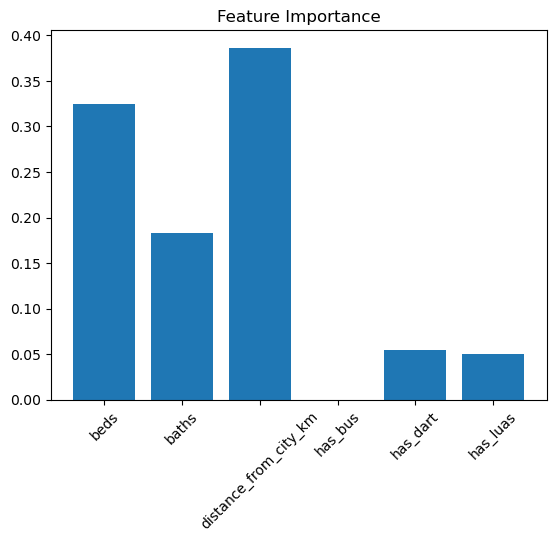

In [7]:
#Feature Importance
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_
feature_names = X.columns

plt.bar(feature_names, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

### Feature Importance
- The model establishes which features have the most impact on price prediction. 
- Among the most significant factors, there are distance to the city centre and the number of bedrooms.

## Key Insights

- Dublin is a place that is very sensitive to property prices.
There are also more expensive properties as they are nearer to the city centre.
- Transport accessibility (LUAS, DART) enhances the value of property.
- Marginal-price of bigger homes is higher.
- Market is definite in price category.

## Recommendations

### For Buyers:
- Take into account suburban areas because it is cheaper.
- Value transport connectivity.
- 
### For Investors:
Invest in well connected areas.
- Target mid-range property.
  
For Platforms:
- Adopt recommendation systems.
  
Use predictive modeling in pricing.

## Deployment Opportunities
This solution may be implemented as:
- Home market recommender system.
- Price prediction tool
- Insight dashboard in real estate.

## Conclusion
The project shows the applicability of web scraping and machine learning in analysing the housing market in Dublin. A combination of clustering and classification allowed generating meaningful insights to help in making better decisions.